## tl;dr
This notebook answers whether changing one game-plan dial matters because it fits the roster, rather than because that dial has one globally optimal setting. Every comparison holds the players, opponent, identity orientation, map order, and seeds fixed.

## Context & Methods
Both teams use mechanically mirrored 75-overall rosters. The neutral control leaves every tactics dial at 50; the treatment moves exactly one designated-team dial to 0 or 100. The four roster shapes are balanced, frag-heavy, tactical, and a two-fragger/three-tactician mix. BO3 and BO5 are reconstructed from the same five deterministic maps.

### Key Assumptions
- Each roster profile is synthetic and deliberately polarized.
- Series do not model between-map fatigue, substitutions, adaptation, or vetoes.
- Percentage-point lift is paired treatment minus neutral-control series wins.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

RUN_DIR = Path('C:\\Users\\aidan\\workspace\\esports-simulator\\ESports Simulator\\runs\\mcp-experiments\\20260719T042507Z-roster-fit-bo3-bo5-100-mirrored')
EFFECTS_PATH = Path('C:\\Users\\aidan\\workspace\\esports-simulator\\ESports Simulator\\analysis\\roster_fit\\output\\tables\\roster_fit_effects.csv')
INTERACTIONS_PATH = Path('C:\\Users\\aidan\\workspace\\esports-simulator\\ESports Simulator\\analysis\\roster_fit\\output\\tables\\roster_fit_interactions.csv')
CONTROL_PATH = Path('C:\\Users\\aidan\\workspace\\esports-simulator\\ESports Simulator\\analysis\\roster_fit\\output\\tables\\control_symmetry.csv')
HEATMAP_PATH = Path('C:\\Users\\aidan\\workspace\\esports-simulator\\ESports Simulator\\analysis\\roster_fit\\output\\figures\\bo3_roster_plan_heatmap.png')
INTERACTION_FIGURE = Path('C:\\Users\\aidan\\workspace\\esports-simulator\\ESports Simulator\\analysis\\roster_fit\\output\\figures\\bo3_fit_interactions.png')
RESPONSE_FIGURE = Path('C:\\Users\\aidan\\workspace\\esports-simulator\\ESports Simulator\\analysis\\roster_fit\\output\\figures\\fit_response_round_margin.png')
DECOMPOSITION_FIGURE = Path('C:\\Users\\aidan\\workspace\\esports-simulator\\ESports Simulator\\analysis\\roster_fit\\output\\figures\\global_vs_roster_decomposition.png')


## Data
### 1. Load paired outcomes and summaries

In [2]:
series = pd.read_csv(RUN_DIR / 'series.csv')
maps = pd.read_csv(RUN_DIR / 'series_maps.csv')
effects = pd.read_csv(EFFECTS_PATH)
interactions = pd.read_csv(INTERACTIONS_PATH)
control = pd.read_csv(CONTROL_PATH)
{'series_rows': len(series), 'map_rows': len(maps), 'effect_cells': len(effects), 'interaction_cells': len(interactions)}

{'series_rows': 6400,
 'map_rows': 32000,
 'effect_cells': 64,
 'interaction_cells': 16}

### 2. Validate the experiment grain

In [3]:
assert len(series) == 6_400
assert len(maps) == 32_000
assert not series.duplicated(['dial','roster_profile','treatment_value','best_of','series_index']).any()
assert not maps.duplicated(['comparison_id','map_index','arm']).any()
paired = maps.pivot(index=['comparison_id','map_index'], columns='arm', values=['map_id','match_seed'])
assert (paired[('map_id','control')] == paired[('map_id','treatment')]).all()
assert (paired[('match_seed','control')] == paired[('match_seed','treatment')]).all()
control.sort_values(['best_of','roster_profile']).reset_index(drop=True)

,roster_profile,best_of,control_win_rate,series_rows
0,balanced,3,0.54,800
1,fraggers,3,0.48,800
2,mixed,3,0.54,800
3,tacticians,3,0.51,800
4,balanced,5,0.47,800
5,fraggers,5,0.44,800
6,mixed,5,0.42,800
7,tacticians,5,0.48,800


## Results
### 3. One plan treatment has different effects across roster shapes

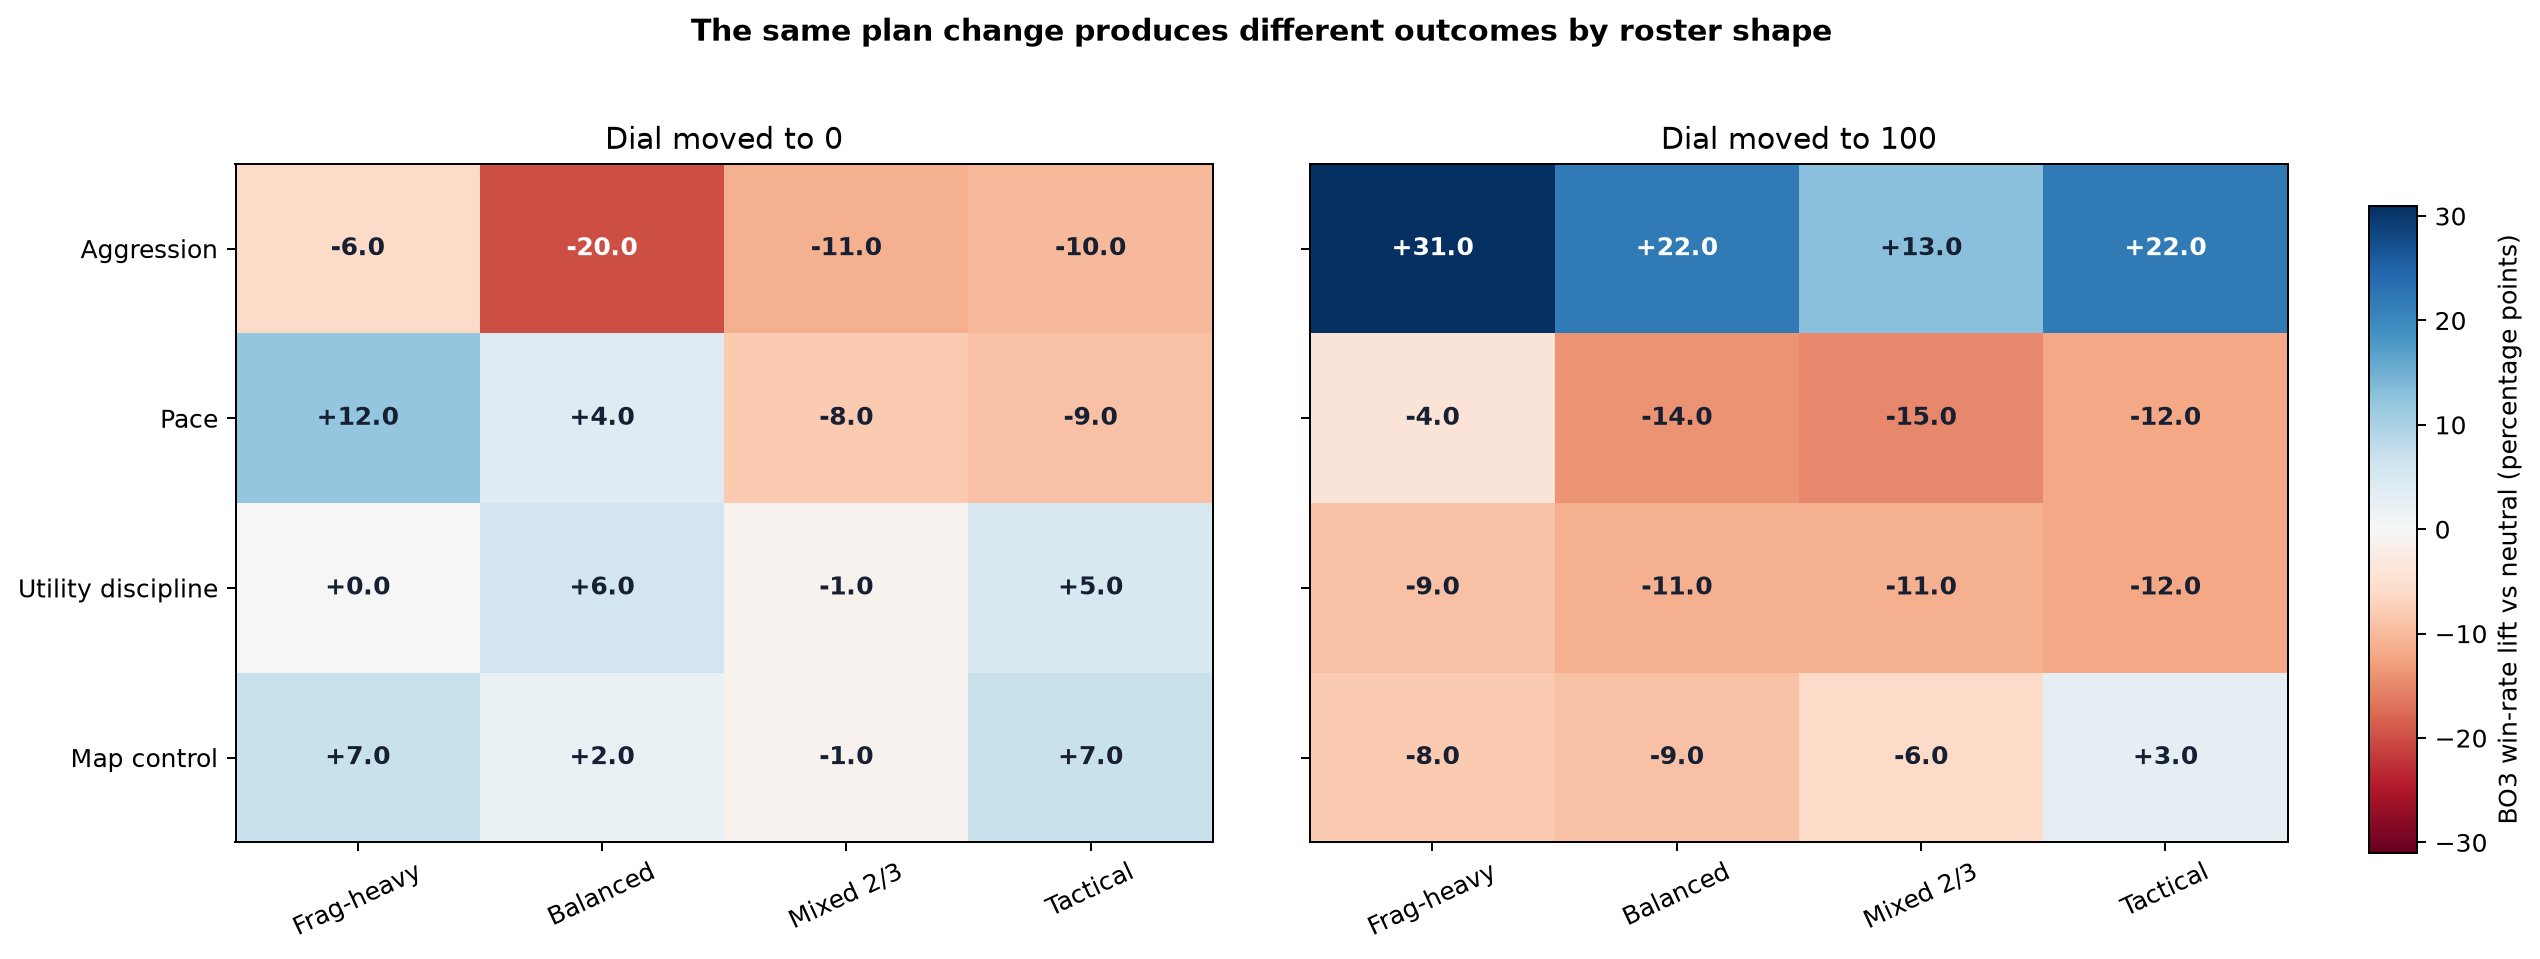

roster_profile                   balanced  fraggers  mixed  tacticians
dial            treatment_value                                       
aggression      0.0                 -20.0      -6.0  -11.0       -10.0
                100.0                22.0      31.0   13.0        22.0
map_control     0.0                   2.0       7.0   -1.0         7.0
                100.0                -9.0      -8.0   -6.0         3.0
pace            0.0                   4.0      12.0   -8.0        -9.0
                100.0               -14.0      -4.0  -15.0       -12.0
util_discipline 0.0                   6.0       0.0   -1.0         5.0
                100.0               -11.0      -9.0  -11.0       -12.0

In [4]:
display(Image(filename=str(HEATMAP_PATH)))
bo3 = effects[effects.best_of.eq(3)].copy()
bo3.pivot_table(index=['dial','treatment_value'], columns='roster_profile', values='series_win_lift_pp').round(1)

### 4. Estimate the causal fit interaction
For aggression and pace, frag-heavy is the aligned roster and tactical is mismatched. For utility discipline and map control, that assignment is reversed. The interaction is the aligned treatment lift minus the mismatched treatment lift on the same seeds.

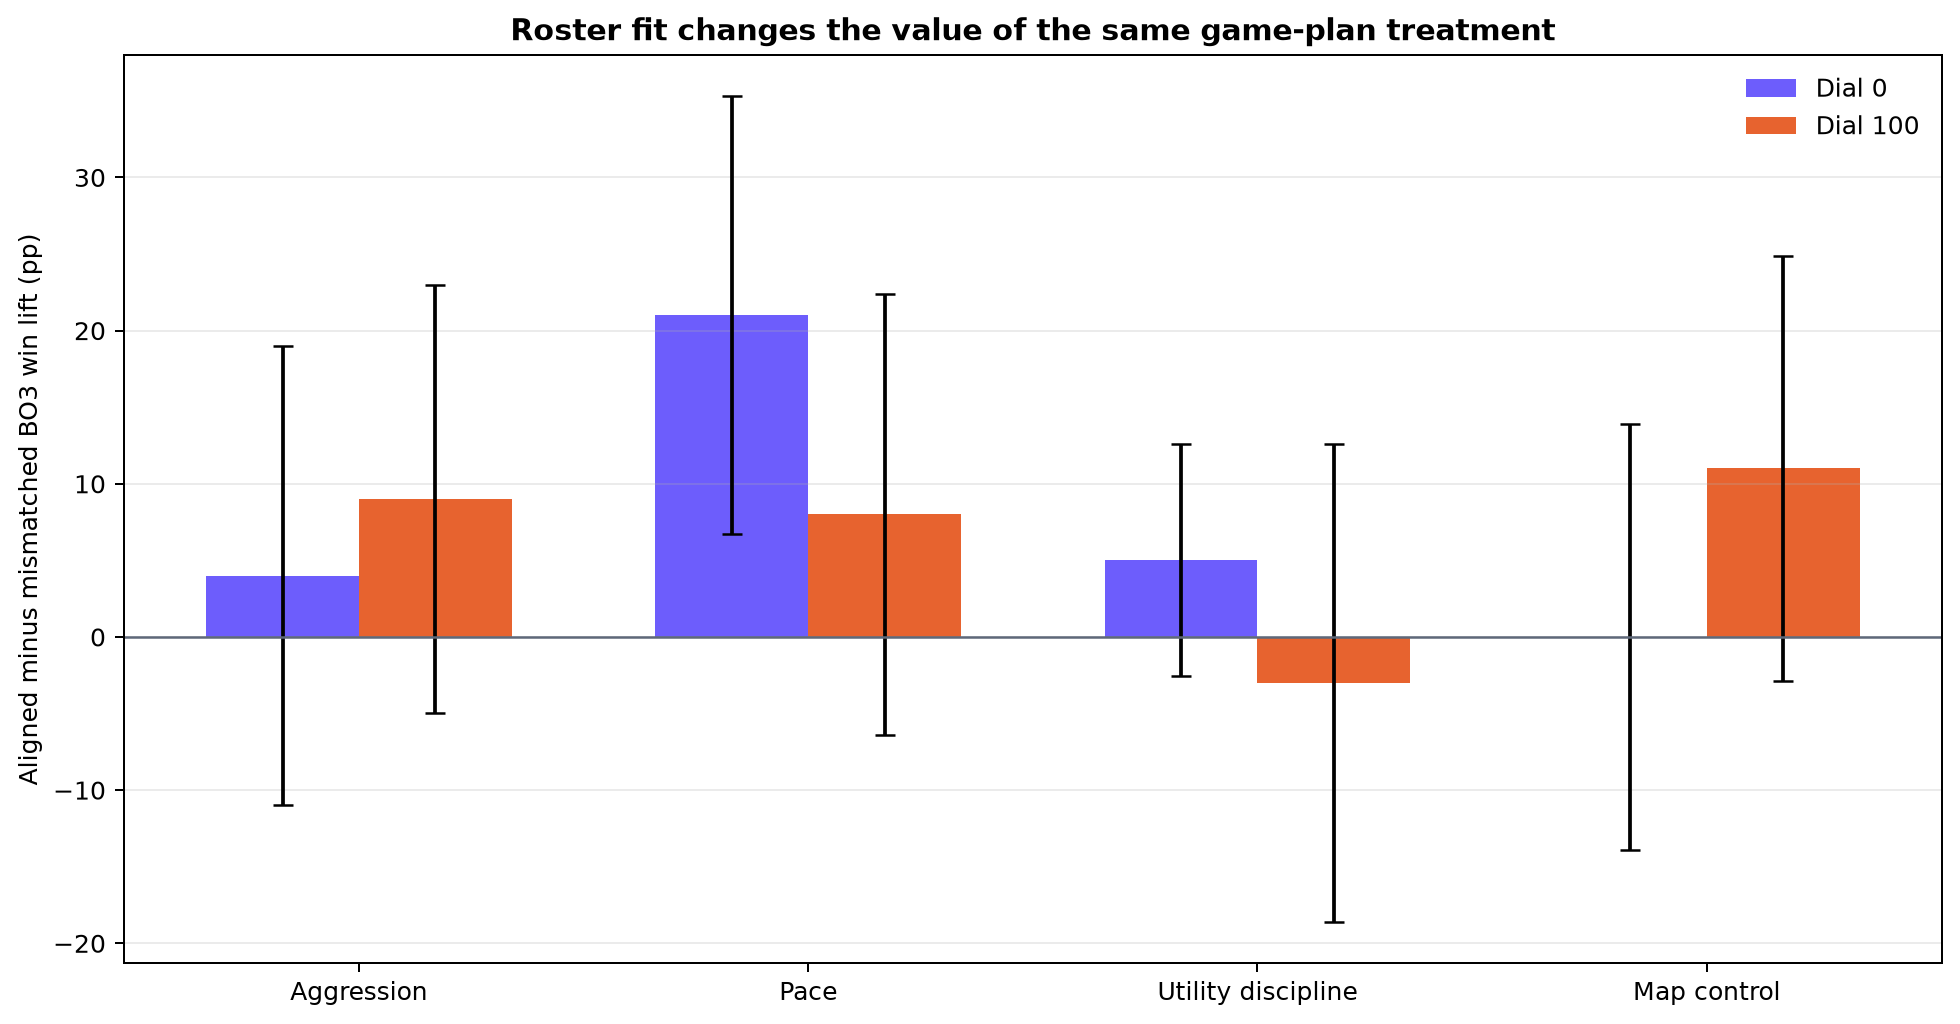

,dial,treatment_value,best_of,aligned_profile,mismatched_profile,series,fit_interaction_win_pp,fit_interaction_win_ci_low,fit_interaction_win_ci_high,fit_interaction_rounds_per_map,fit_interaction_rounds_ci_low,fit_interaction_rounds_ci_high
0,aggression,0.0,3,fraggers,tacticians,100,4.0,-10.98,18.98,0.17,-0.46,0.80
2,aggression,100.0,3,fraggers,tacticians,100,9.0,-4.96,22.96,0.16,-0.41,0.73
4,map_control,0.0,3,tacticians,fraggers,100,0.0,-13.93,13.93,0.52,0.10,0.93
6,map_control,100.0,3,tacticians,fraggers,100,11.0,-2.90,24.90,0.70,0.23,1.18
8,pace,0.0,3,fraggers,tacticians,100,21.0,6.71,35.29,0.32,-0.15,0.78
10,pace,100.0,3,fraggers,tacticians,100,8.0,-6.39,22.39,0.24,-0.29,0.78
12,util_discipline,0.0,3,tacticians,fraggers,100,5.0,-2.57,12.57,0.35,0.06,0.64
14,util_discipline,100.0,3,tacticians,fraggers,100,-3.0,-18.62,12.62,0.36,-0.24,0.97
1,aggression,0.0,5,fraggers,tacticians,100,13.0,-1.91,27.91,0.28,-0.19,0.75
3,aggression,100.0,5,fraggers,tacticians,100,15.0,-0.35,30.35,0.10,-0.33,0.53


In [5]:
display(Image(filename=str(INTERACTION_FIGURE)))
interactions.sort_values(['best_of','dial','treatment_value']).round(2)

### 5. Separate global dial direction from roster-specific fit

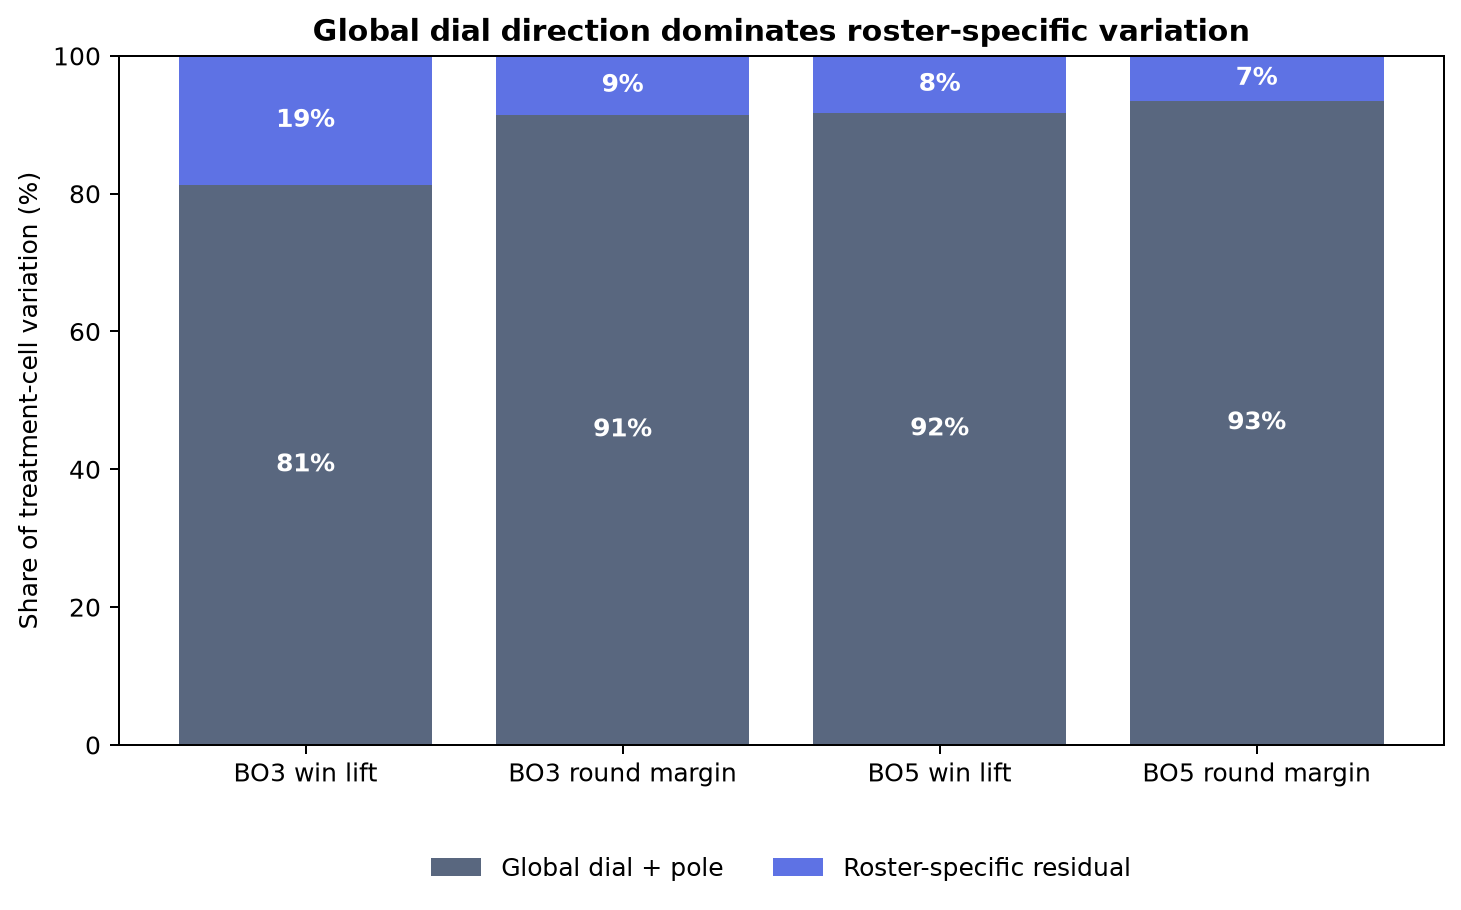

,best_of,outcome,global_dial_pole_share,roster_specific_share,total_ss
0,3,series_win_lift_pp,0.812779,0.187221,4405.218750
1,3,round_margin_added_per_map,0.914366,0.085634,41.311530
2,5,series_win_lift_pp,0.917174,0.082826,6148.468750
3,5,round_margin_added_per_map,0.934819,0.065181,40.360082


In [6]:
display(Image(filename=str(DECOMPOSITION_FIGURE)))
pd.read_csv(EFFECTS_PATH.parent / 'global_vs_roster_decomposition.csv')

### 6. Check whether the engine's declared fit edge predicts rounds

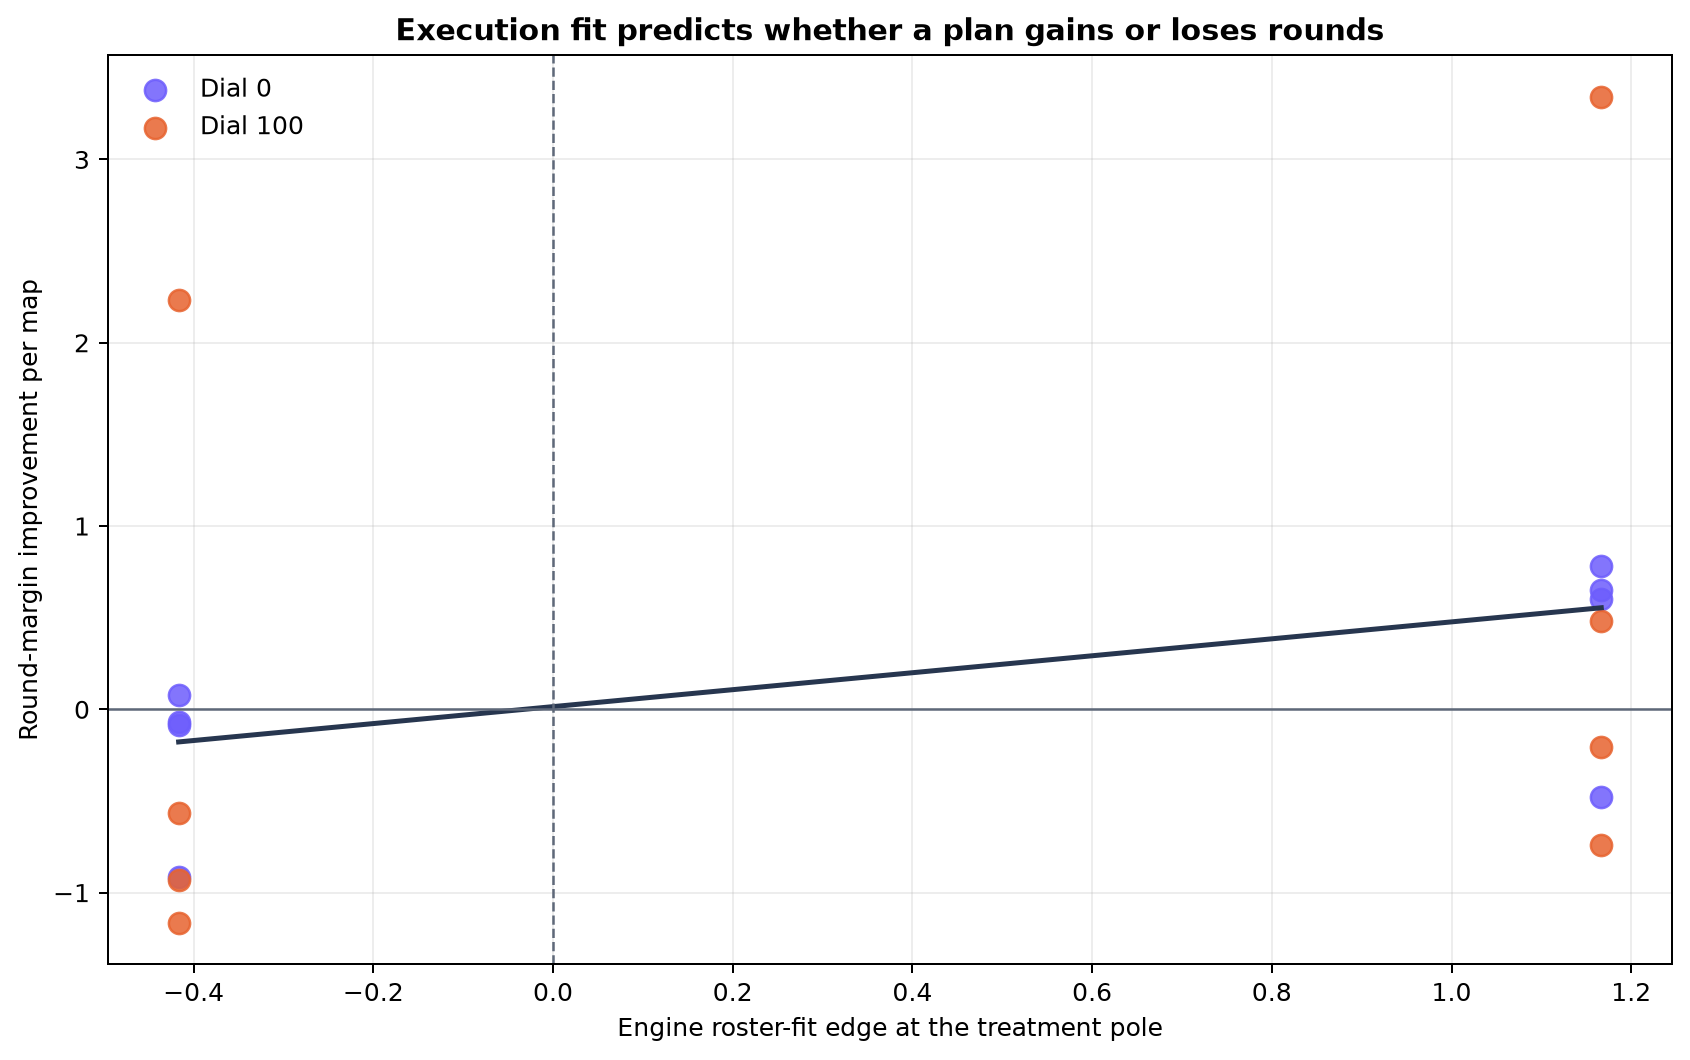

,roster_profile,best_of,mean_win_lift_pp,mean_round_margin_added
0,balanced,3,-2.50,0.28
1,balanced,5,1.75,0.23
2,fraggers,3,2.88,0.21
3,fraggers,5,3.12,0.11
4,mixed,3,-5.00,-0.02
5,mixed,5,5.38,-0.07
6,tacticians,3,-0.75,0.16
7,tacticians,5,-1.12,-0.00


In [7]:
display(Image(filename=str(RESPONSE_FIGURE)))
effects.groupby(['roster_profile','best_of'], as_index=False).agg(
    mean_win_lift_pp=('series_win_lift_pp','mean'),
    mean_round_margin_added=('round_margin_added_per_map','mean'),
).round(2)

## Takeaways
- The experiment contains 6,400 paired series rows.
- After controlling for dial, pole, and format, declared fit and round-margin lift correlate 0.85.
- Global dial and pole choice explains 91.4% of BO3 round-margin variation across treatment cells; roster-specific variation accounts for 8.6%.
- The observed BO3 aligned-minus-mismatched interactions range from -3.0 to +21.0 percentage points.
- Use the interaction estimates, not the largest raw dial effect, to judge whether the game rewards adapting a plan to the roster.